# Objective and Goal

1. The objective and goal for this project is to identify patterns and differences in characteristics between customers who have churned and those who 

haven't by running Analysis on a Telecommunication churn dataset. The insights i shall gain will be beneficial to the management as they will use 

these insights to develop strategies to retain customers and reduce he rate of churn among them.






2. The second objective and goal for this project is to develop a predictive model which will learn from the patterns in this dataset thereby gain the ability to 

predicts weather a customer is going to churn or not condsidering their interactions with services provided by the company which will assist the management 

identify and address customer concerns enhancing customer retention rates.

In [178]:
#importing the necessary labraries needed for this project
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
sns.set()
sns.set_palette("Dark2")
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, roc_auc_score
from sklearn.model_selection import train_test_split,RandomizedSearchCV, KFold, GridSearchCV, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

In [179]:
#Reading the dataframe into the notebook
df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df = df[df['TotalCharges'] != ' ']# exclude rows which contain empty strings as their total_charges value

In [180]:
#printing the dataframe's first five rows of the dataset
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [181]:
#outputing the basic information about dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 
 17  

In [182]:
"""
This code shows the data type of columns in this dataset running this code will help me supervise and ensure that 
each column is assigned the appropriate data type based on the type of data it contains
"""
df.dtypes


customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

# Data cleaning

#Dropping unneeded column
# Duplicate drop removed (see next cell)

In [183]:
#Dropping unneeded column
df.drop("customerID", axis = 1, inplace=True)

In [184]:
df['SeniorCitizen'] = df['SeniorCitizen'].replace({0 :'No', 1 : 'Yes'})

# Categorical columns 

In [185]:
cat_cols = [
     'gender','SeniorCitizen','Partner','Dependents',
       'PhoneService','MultipleLines', 'InternetService',
       'OnlineSecurity','OnlineBackup', 'DeviceProtection','TechSupport',
       'StreamingTV', 'StreamingMovies','Contract','PaperlessBilling',
       'PaymentMethod','Churn'
]

for col in cat_cols:
    df[col] = df[col].astype('category')

# Numerical Columns

In [186]:
"""
The monthly and total_charges columns not left behind contain numerical data but has an object datatype 
and as such we shall change it to a float64 data type
"""



#The total charges column was found having a wrong data type and as such I changed it to the appropriate type
df[['TotalCharges', 'MonthlyCharges']] = df[['TotalCharges', 'MonthlyCharges']].astype('float')
                                     



In [187]:
#Checking for missing values in this dataset
df.isna().sum().sort_values()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

# Exploratory Data Analysis

# What Is The Percentage Of Churn Among Customers?

In [188]:
#Grouping customers based on their churn status
churn_grouping = df['Churn'].value_counts(normalize = True)*100
churn_grouping.to_frame('Percentage')

,Percentage
Churn,
No,73.421502
Yes,26.578498


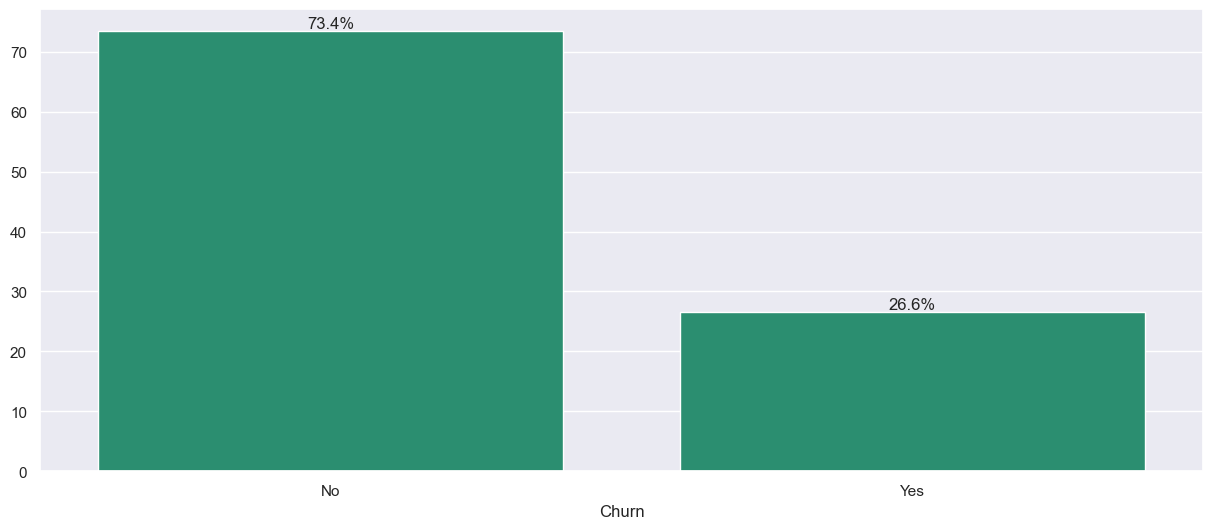

In [189]:
plt.figure(figsize = (15,6))
sns.barplot(
    x=churn_grouping.index, 
    y=churn_grouping.values,
)

# Add percentage annotations on top of each bar
for i, v in enumerate(churn_grouping.values):
    plt.text(i, v, f'{v:.1f}%', ha='center', va='bottom')

plt.show()

## A visualization on the distribution of values among the categorical columns

review = df[[ 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod']]
for i in review.columns:
    percentage = (df[i].value_counts(normalize=True) * 100).round(1)
    print(percentage.to_frame(name='Percentage'))
    plt.figure(figsize=(15, 4))
    sns.barplot(x=review[i].value_counts().index, 
                y=review[i].value_counts(),
            ).set(title=i.upper(), xlabel='Label', ylabel='Frequency')
    #plt.xticks(rotation = 45)
    plt.show()

The Visualization above shows the distribution of values among the following columns:

1. Gender: Categorizes customers as male or female.


2. Senior Citizen: Indicates whether a customer is a senior citizen (Yes / No).


3. Partner: Indicates whether a customer has a partner (Yes / No).


4. Dependents: Indicates whether a customer has dependents (Yes / No).


5. Phone Service: Indicates whether a customer has a phone service plan (Yes / No).


6. Multiple Lines: Indicates whether a customer has multiple phone lines (No phone service / Yes / No).


7. Internet Service: Indicates whether a customer has an internet service plan (DSL / Fiber optic / No).


8. Online Security: Indicates whether a customer subscribes to online security services (Yes / No / No internet service).


9. Online Backup: Indicates whether a customer subscribes to online backup services (Yes / No / No internet service).


10. Device Protection: Indicates whether a customer subscribes to device protection services (Yes / No / No internet service).


11. Tech Support: Indicates whether a customer utilizes technical support services (Yes / No / No internet service).


12. StreamingTV: Indicates whether a customer subscribes to a streaming TV service (Yes / No / No internet service).


13. Streaming Movies: Indicates whether a customer subscribes to a streaming movie service (Yes / No / No internet service).


14. Contract: Indicates whether a customer has a contract with the company (Month-to-month / One year / Two year).


15. Paperless Billing: Indicates whether a customer uses paperless billing (Yes / No).


16. Payment Method: Categorizes the customer's payment method (Electronic check / Mailed check / Bank transfer (automatic) /   Credit card (automatic)).





I used bar charts to visualize the distribution of unique values within each category and also show thier distribution via percentage among customers, this helps us understand the general composition of the customer base. 



This initial exploration provides a basic understanding of the data, the next steps will involve analyzing the churn rate.

## What is the distribution of churn among customers(gender based)?

churn_gender = (df.groupby('gender')['Churn'].value_counts(normalize = True)*100).round(1)
churn_gender.to_frame()

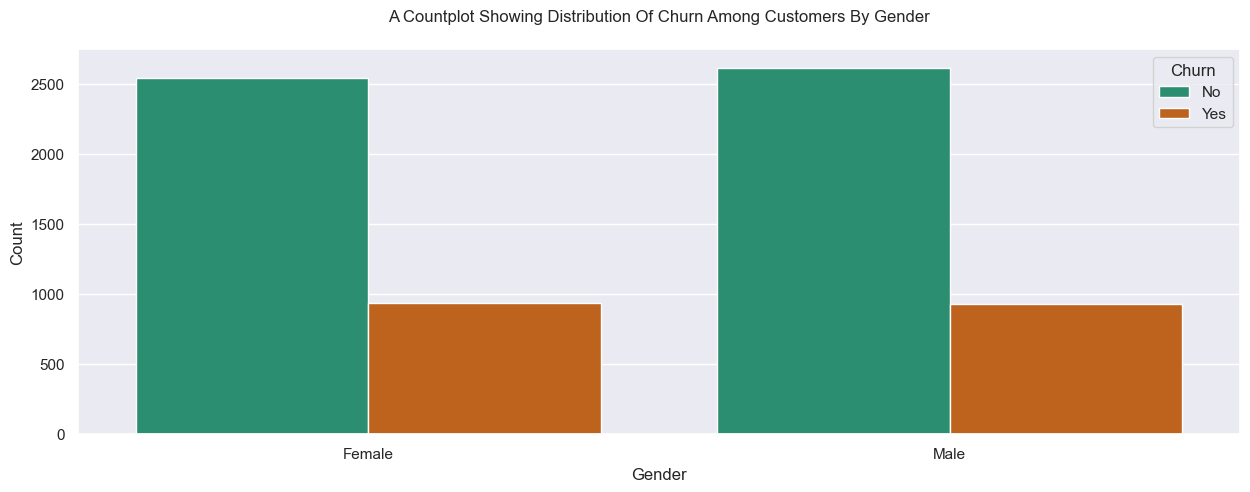

In [190]:
#Data visualization on churn analysis
plt.figure(figsize = (15, 5))
sns.countplot(
    x = "gender",
    hue = "Churn",
    data = df
    
)
plt.title("A Countplot Showing Distribution Of Churn Among Customers By Gender", pad = 20)
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

The data analysis above shows that Majority of customers who churn are Women with a count of 939 female customers who churned out of 3488 female customers

## What Is The Distribution Of Senior Citizenship Among Customer?

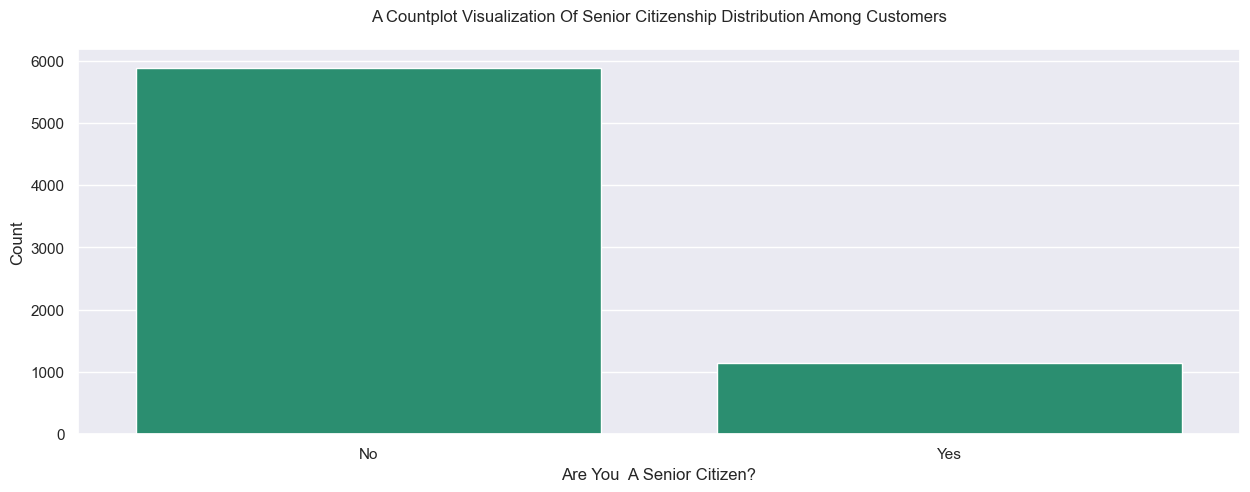

In [191]:
plt.figure(figsize=(15, 5))
sns.countplot(
    x = df["SeniorCitizen"]
    
)
plt.title('A Countplot Visualization Of Senior Citizenship Distribution Among Customers', pad = 20)
plt.xlabel('Are You  A Senior Citizen?')
plt.ylabel('Count')
plt.show()

In [192]:
(df["SeniorCitizen"].value_counts(normalize = True)*100).round(1).to_frame()

,proportion
SeniorCitizen,
No,83.8
Yes,16.2


Data analysis show that 16% out of 100% of our customers are Senior citizens while 84% of customers are Junior citizens

# What Is The Distribution Of Churn Among Citizen Class?

In [193]:
(df.groupby("SeniorCitizen")["Churn"].value_counts(normalize = True)*100).round(1).to_frame()

proportion
SeniorCitizen Churn            
No            No           76.3
              Yes          23.7
Yes           No           58.3
              Yes          41.7

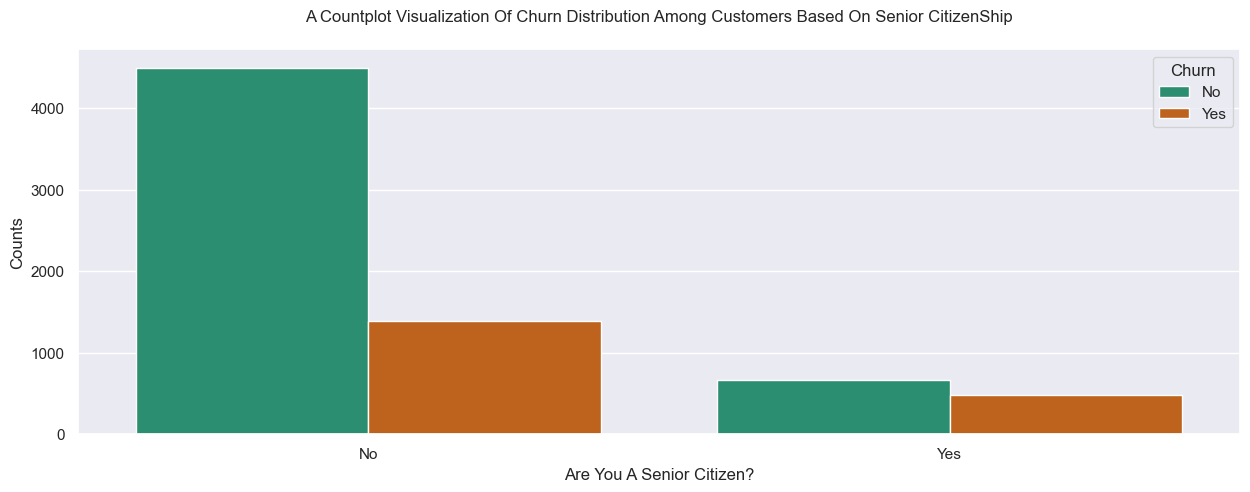

In [194]:
#Data visualization on churn analysis
plt.figure(figsize = (15, 5))
sns.countplot(
    x = "SeniorCitizen",
    hue = "Churn",
    data = df
)
plt.title('A Countplot Visualization Of Churn Distribution Among Customers Based On Senior CitizenShip', pad = 20)
plt.xlabel('Are You A Senior Citizen?')
plt.ylabel('Counts')
plt.show()

From the data analysis above insights has been gathered that
1. 76% of customers from the junior citizen class didn't churn while 24% of customers from the junior class did churn.
2. 58% of customers from the senior citiizen class didn't churn while 42% of customers from this class of citizens did churn.

This implies that services provided by the company is much more enjoyed by customers from the junior citizen class. 

## What Is The Distribution Of Churn Among Customers With Partners?

In [195]:
(df.groupby("Partner")["Churn"].value_counts(normalize = True)*100).round(1).to_frame()

proportion
Partner Churn            
No      No           67.0
        Yes          33.0
Yes     No           80.3
        Yes          19.7

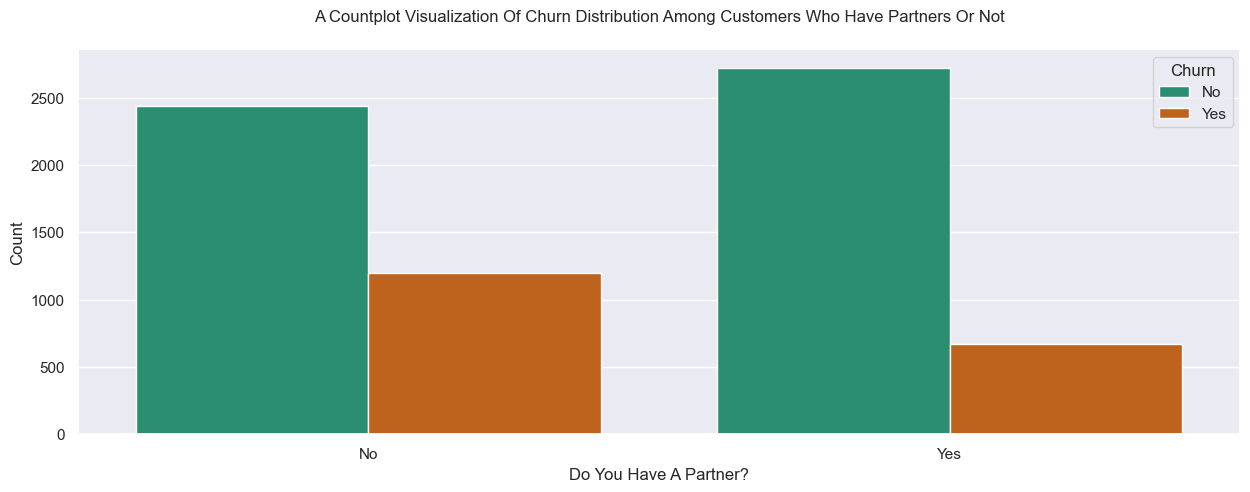

In [196]:
plt.figure(figsize = (15, 5))
sns.countplot(
    x = "Partner",
    hue = "Churn",
    data = df
    )
plt.title("A Countplot Visualization Of Churn Distribution Among Customers Who Have Partners Or Not", pad = 20)
plt.xlabel("Do You Have A Partner?")
plt.ylabel('Count')
plt.show()

Customers without partners have a higher distribution of churn as compared to customers with partners indicating this could be that customers who share the bills last longer

## What Is The Distribution Of Churn Among Customers With Partners Based On Gender?

(df.groupby(["gender", "Partner"])["Churn"].value_counts(normalize = True) * 100).round(1).to_frame()

I have performed some statistical analysis on this dataset and here are my key observations:

Gender Insight: Male and female customers without partners have higher churn rates compared to those with partners.


Partner Effect: Having a partner significantly reduces churn, with males showing slightly higher retention when they have partners

# Recommendations
Retention Strategy: Female customers without partners (34.4% churn) might need targeted offers or engagement strategies to improve retention.
Actionable Insights:

Implement customer retention programs tailored for single individuals (especially females).
Study customer engagement and satisfaction among partnered customers to replicate success factors.

# What Is The Distribution Of Churn Among Customers Based On Dependents?

In [197]:
(df.groupby("Dependents")["Churn"].value_counts(normalize = True) * 100 ).round(1).to_frame()

proportion
Dependents Churn            
No         No           68.7
           Yes          31.3
Yes        No           84.5
           Yes          15.5

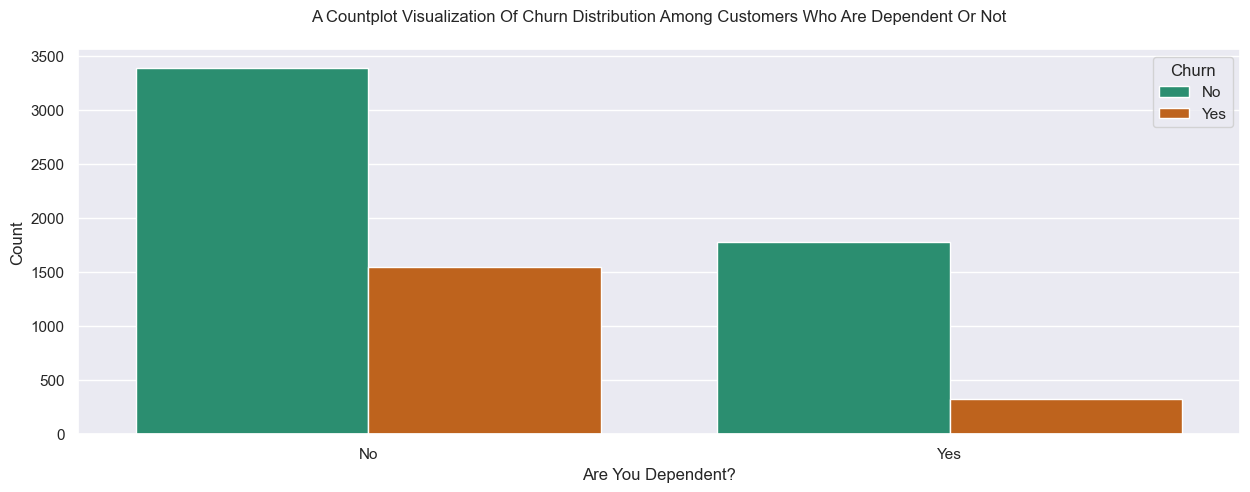

In [198]:
plt.figure(figsize = (15, 5))
sns.countplot(
    x = "Dependents",
    data = df,
    hue = 'Churn'
)
plt.title("A Countplot Visualization Of Churn Distribution Among Customers Who Are Dependent Or Not", pad = 20)
plt.xlabel('Are You Dependent?')
plt.ylabel('Count')
plt.show()

Data analysis shows that dependent customers have the highest churn rate as compared to  undependent customers

# Based On Gender What Is The Distribution Of Churn Among Customers Who Are Dependent?

In [199]:
(df.groupby(["gender", "Dependents"])["Churn"].value_counts(normalize = True) * 100).round(1).to_frame()

proportion
gender Dependents Churn            
Female No         No           68.5
                  Yes          31.5
       Yes        No           83.9
                  Yes          16.1
Male   No         No           68.9
                  Yes          31.1
       Yes        No           85.0
                  Yes          15.0

# What Is The Churn Rate Of Customers If They Use A Phone Service Or Not?

In [200]:
(df.groupby('PhoneService')["Churn"].value_counts(normalize = True) * 100).round(2).to_frame()

proportion
PhoneService Churn            
No           No          75.00
             Yes         25.00
Yes          No          73.25
             Yes         26.75

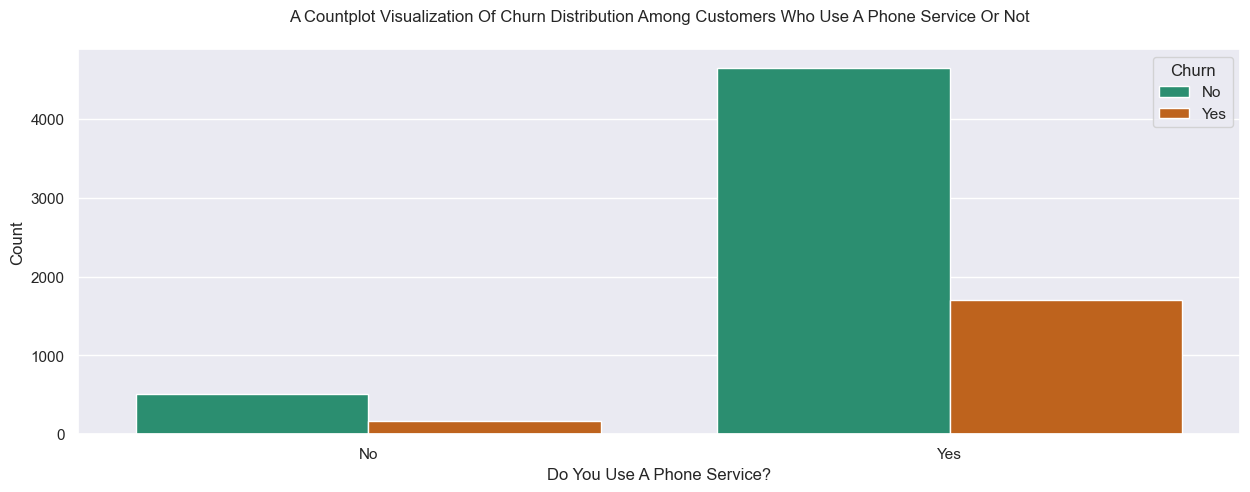

In [201]:
plt.figure(figsize = (15, 5))
sns.countplot(
    x = 'PhoneService',
    hue = "Churn",
    data = df
    )
plt.title("A Countplot Visualization Of Churn Distribution Among Customers Who Use A Phone Service Or Not", pad = 20)
plt.xlabel('Do You Use A Phone Service?')
plt.ylabel('Count')
plt.show()

As seen in the visualization and statistics above the rate of churn among customers with or without a phone service subcription is very low as majority of them do not churn.

## What is the churn rate of customers based on they number of lines the own?

(df.groupby('MultipleLines')["Churn"].value_counts(normalize = True) * 100 ).round(1).to_frame()

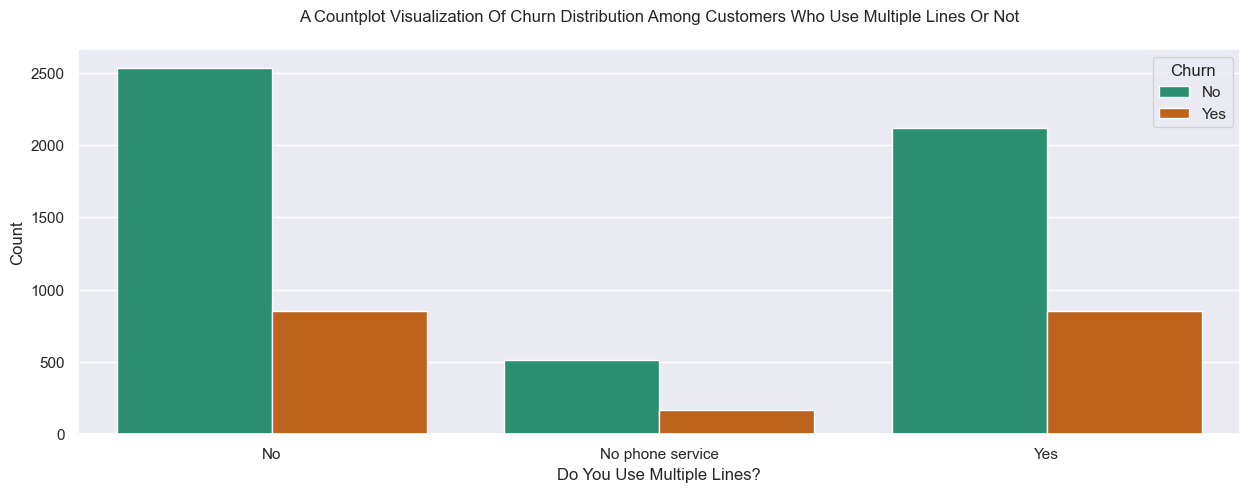

In [202]:
plt.figure(figsize = (15, 5))
sns.countplot(
    x = 'MultipleLines',
    hue = "Churn",
    data = df
    )
plt.title("A Countplot Visualization Of Churn Distribution Among Customers Who Use Multiple Lines Or Not", pad = 20)
plt.xlabel('Do You Use Multiple Lines?')
plt.ylabel('Count')
plt.show()

The churn rate among customers who have multiple line is higher as compared to those with just a line and those without a phone service

# What Is The Churn Rate Between Customers Who Use Internet Services Or Not?

In [203]:
(df.groupby('InternetService')["Churn"].value_counts(normalize = True) * 100).round(1).to_frame()

proportion
InternetService Churn            
DSL             No           81.0
                Yes          19.0
Fiber optic     No           58.1
                Yes          41.9
No              No           92.6
                Yes           7.4

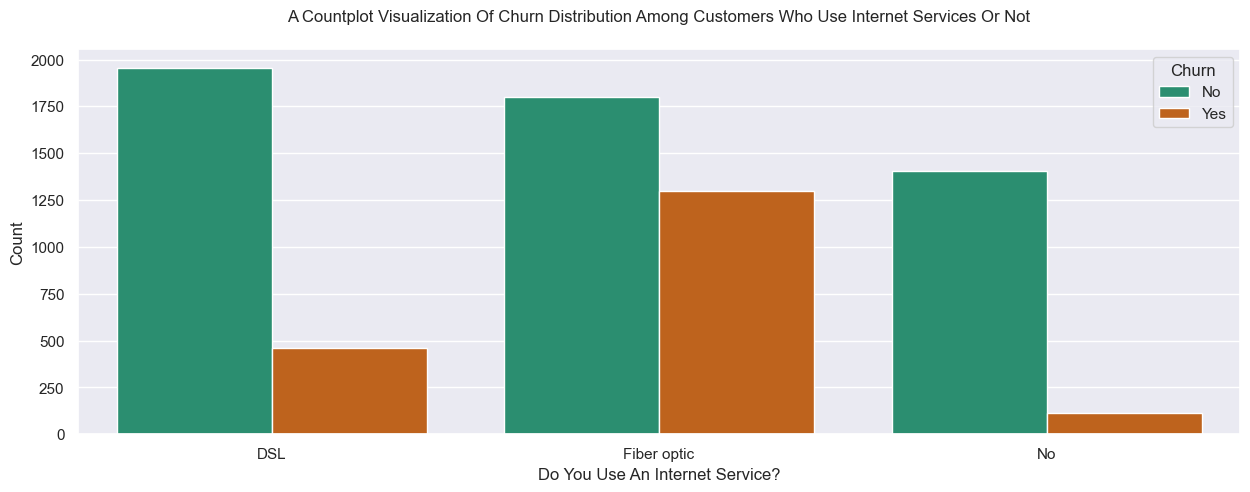

In [204]:
plt.figure(figsize = (15, 5))
sns.countplot(
    x = 'InternetService',
    hue = "Churn",
    data = df
    )
plt.title("A Countplot Visualization Of Churn Distribution Among Customers Who Use Internet Services Or Not", pad = 20)
plt.xlabel('Do You Use An Internet Service?')
plt.ylabel('Count')
plt.show()

a high number of customers who use the fiber optic type of internet service churn does this mean that the service provide is not worth it? for out of a 100% of customers who use this service 42% of them turn to churn.
Also it is seen that customers with no internet subscription remain loyal to the company as a litte percentage of 7 churns out of a 100% OF THEM and the customers who use the DSL type of internet service have a churn rate of 19%.

# What Is The Churn Rate Between Customers Who Make Use of An Online Security And Those Who Don't?

In [205]:
(df.groupby('OnlineSecurity')["Churn"].value_counts(normalize = True) * 100).round(1).to_frame()

proportion
OnlineSecurity      Churn            
No                  No           58.2
                    Yes          41.8
No internet service No           92.6
                    Yes           7.4
Yes                 No           85.4
                    Yes          14.6

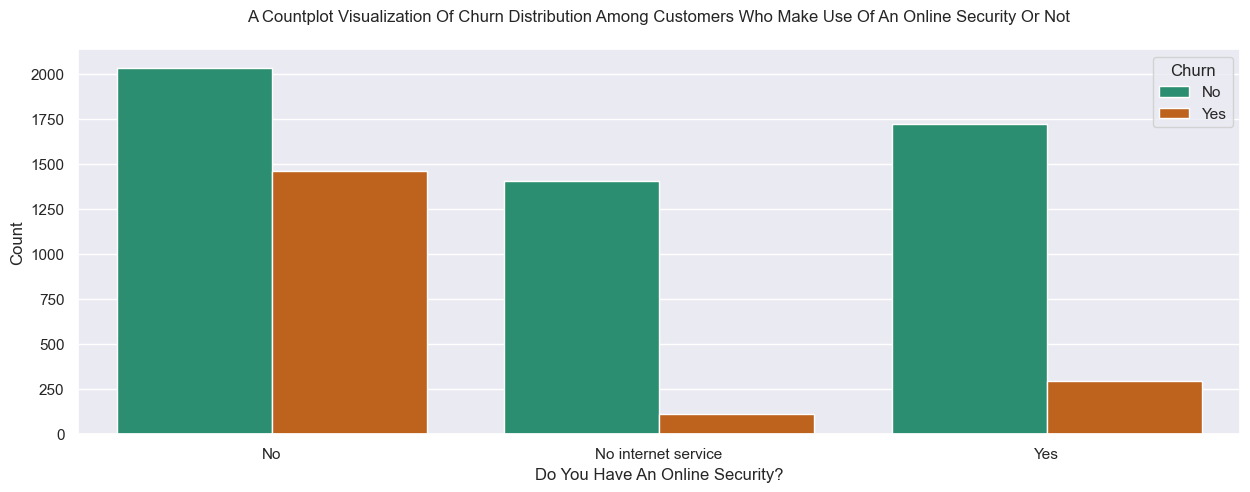

In [206]:
plt.figure(figsize = (15, 5))
sns.countplot(
    x = 'OnlineSecurity',
    hue = "Churn",
    data = df
    )
plt.title("A Countplot Visualization Of Churn Distribution Among Customers Who Make Use Of An Online Security Or Not", pad = 20)
plt.xlabel('Do You Have An Online Security?')
plt.ylabel('Count')
plt.show()

# What Is The Churn Rate Of Customers On The Basis Of Having An Online Backup?

In [207]:
(df.groupby('OnlineBackup')["Churn"].value_counts(normalize = True) * 100).round(1).to_frame()

proportion
OnlineBackup        Churn            
No                  No           60.1
                    Yes          39.9
No internet service No           92.6
                    Yes           7.4
Yes                 No           78.4
                    Yes          21.6

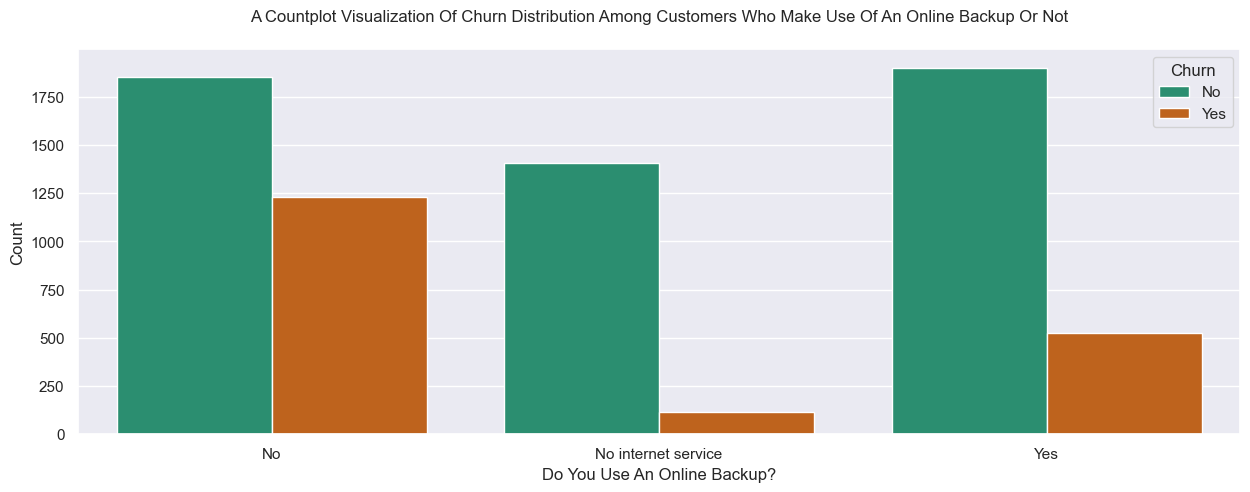

In [208]:
plt.figure(figsize = (15, 5))
sns.countplot(
    x = 'OnlineBackup',
    hue = "Churn",
    data = df
    )
plt.title("A Countplot Visualization Of Churn Distribution Among Customers Who Make Use Of An Online Backup Or Not", pad = 20)
plt.xlabel('Do You Use An Online Backup?')
plt.ylabel('Count')
plt.show()

Analysis shows that more them three quarter of customers who use the online backup service do not churn and 40% of customers who do not use this servise churn and 93% out of the remaining 22% of customers who do not use an internet service do noot churn too

# What Is The Churn Rate Among Customers Who Use A Device protection And Those Who Don't?

In [209]:
(df.groupby('DeviceProtection')["Churn"].value_counts(normalize = True) * 100).round(1).to_frame()

proportion
DeviceProtection    Churn            
No                  No           60.9
                    Yes          39.1
No internet service No           92.6
                    Yes           7.4
Yes                 No           77.5
                    Yes          22.5

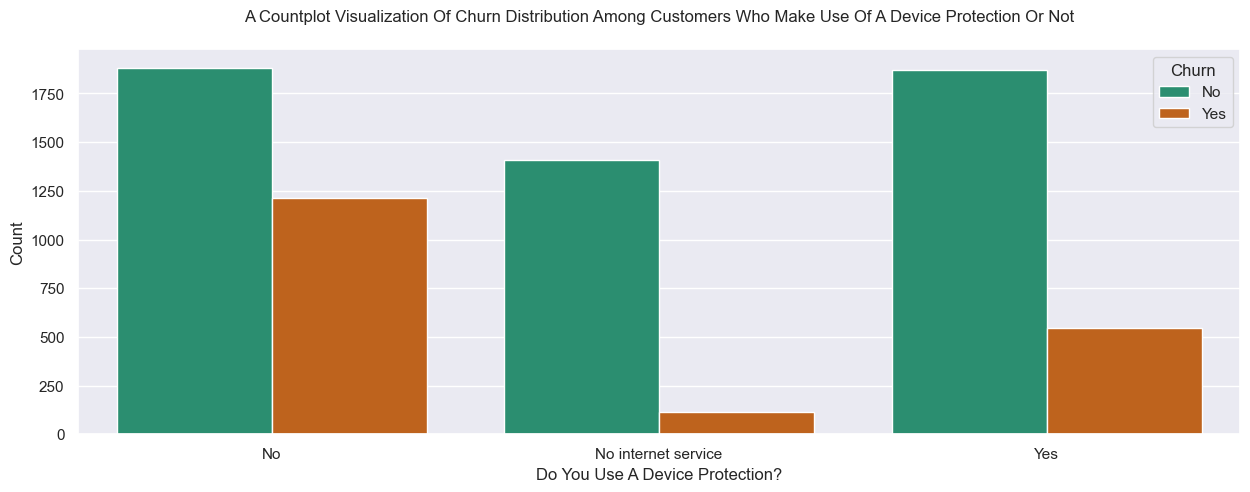

In [210]:
plt.figure(figsize = (15, 5))
sns.countplot(
    x = 'DeviceProtection',
    hue = "Churn",
    data = df
    )
plt.title("A Countplot Visualization Of Churn Distribution Among Customers Who Make Use Of A Device Protection Or Not", pad = 20)
plt.xlabel('Do You Use A Device Protection?')
plt.ylabel('Count')
plt.show()

Critical analysis show that 39% of customers who do not use the device protection service provided by the company churn this might be a sign that the company needs step up thier device protection adverts format to customers as these customers may not have uused this serivce and churn due to ignorance as it is seen that a good rate of 77% of customers who use this service remain loyal to the company.

# What Is The Churn Rate Among Customers Who Used Tech Support Or Not?

In [211]:
(df.groupby('TechSupport')["Churn"].value_counts(normalize = True) * 100).round(2).to_frame()

proportion
TechSupport         Churn            
No                  No          58.35
                    Yes         41.65
No internet service No          92.57
                    Yes          7.43
Yes                 No          84.80
                    Yes         15.20

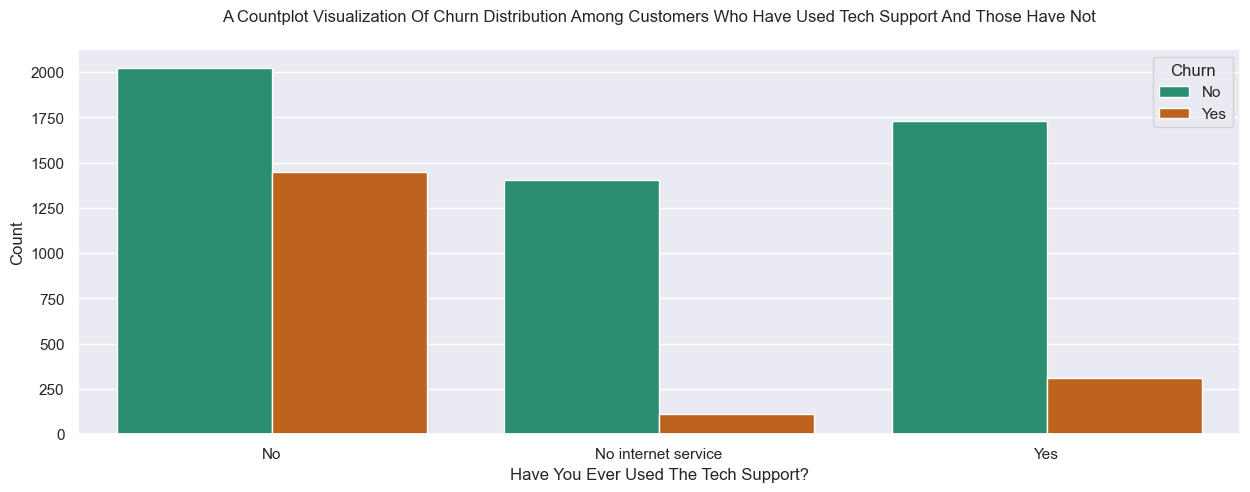

In [212]:
plt.figure(figsize = (15, 5))
sns.countplot(
    x = 'TechSupport',
    hue = "Churn",
    data = df
    )
plt.title("A Countplot Visualization Of Churn Distribution Among Customers Who Have Used Tech Support And Those Have Not", pad = 20)
plt.xlabel('Have You Ever Used The Tech Support?')
plt.ylabel('Count')
plt.show()

Analysis show that customers who do not use a tech support have a churn rate of 42% which can be a huge set back for the company. Also it is seen in this analysis that there is a low rate of 15% percentage for churn among customers who use a tech support.

## What's The Churn Rate Among Customers Who Subscried to a streaming TV Or Not?

The analysis and statistics above show that 40% out of 78% of customers who use an internet service have a subscription for a streaming TV service and 38% of customers do not have a streaming TV subscription.

In [213]:
(df.groupby('StreamingTV')["Churn"].value_counts(normalize = True) * 100).round(1).to_frame()

proportion
StreamingTV         Churn            
No                  No           66.5
                    Yes          33.5
No internet service No           92.6
                    Yes           7.4
Yes                 No           69.9
                    Yes          30.1

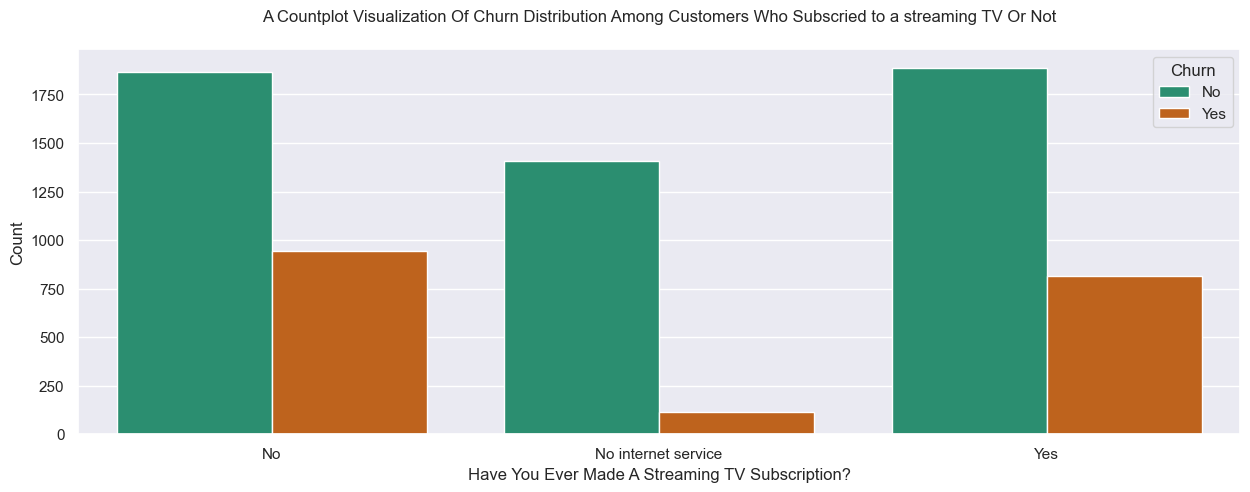

In [214]:
plt.figure(figsize = (15, 5))
sns.countplot(
    x = 'StreamingTV',
    hue = "Churn",
    data = df
    )
plt.title("A Countplot Visualization Of Churn Distribution Among Customers Who Subscried to a streaming TV Or Not", pad = 20)
plt.xlabel('Have You Ever Made A Streaming TV Subscription?')
plt.ylabel('Count')
plt.show()

analysing the streaming tv column by churn it is seen that 34% of customers who do not have this subscription churn while 66% OF them do not also as seen in the visualization and statistics above 70% of customers who subscribed to a streaming TV didn't churn while 30% of them did churn

# What Is The Churn Rate Among Customers Who Stream Movies And Those Who Don't?

The analysis and statistics above show that 40% out of 78% of customers who use an internet service have a subscription for a streaming movies service and 38% of customers do not have a streaming movies subscription.

In [215]:
(df.groupby('StreamingMovies')["Churn"].value_counts(normalize = True) * 100).round(1).to_frame()

proportion
StreamingMovies     Churn            
No                  No           66.3
                    Yes          33.7
No internet service No           92.6
                    Yes           7.4
Yes                 No           70.0
                    Yes          30.0

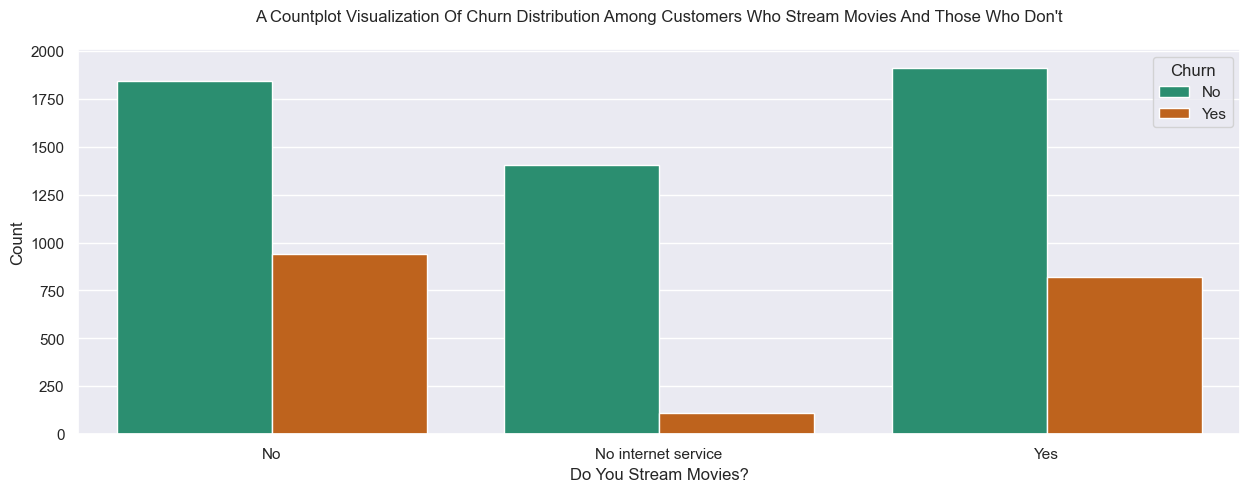

In [216]:
plt.figure(figsize = (15, 5))
sns.countplot(
    x = 'StreamingMovies',
    hue = "Churn",
    data = df
    )
plt.title("A Countplot Visualization Of Churn Distribution Among Customers Who Stream Movies And Those Who Don't", pad = 20)
plt.xlabel('Do You Stream Movies?')
plt.ylabel('Count')
plt.show()

Now analyzing the churn rate it is seen from the statistics and visualization above that out of the 38% percentage of customers who do not have a streaming movies subscripiton, 34% of them churn while 66% don't also analyzing for those with this subscription, there is a 70% non churn rate and a 30% churn rate 

# What Is The Churn Rate For Customers Based On Their Contract Type?

In [217]:
(df.groupby('Contract')["Churn"].value_counts(normalize = True) * 100 ).round(1).to_frame()

proportion
Contract       Churn            
Month-to-month No           57.3
               Yes          42.7
One year       No           88.7
               Yes          11.3
Two year       No           97.2
               Yes           2.8

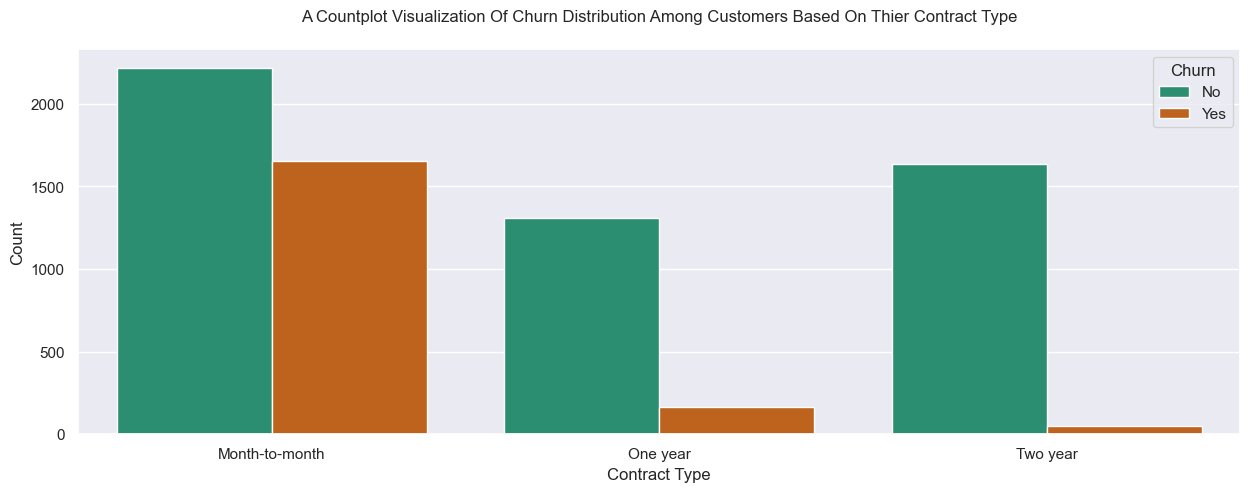

In [218]:
plt.figure(figsize = (15, 5))
sns.countplot(
    x = 'Contract',
    hue = "Churn",
    data = df
    )
plt.title("A Countplot Visualization Of Churn Distribution Among Customers Based On Thier Contract Type", pad = 20)
plt.xlabel('Contract Type')
plt.ylabel('Count')
plt.show()

Now for the analysis of churn based on the type of contract a customer uses it is seen that the contract with the highest 

churn rate from customers is the month to month contract category where majority of the company customers fall and the contract 

category with the least churn rate and highest non churn rate is the two years contract which is the category that comes second in number of customers.

# What Is The Churn Rate Of Customers On The Basis Of If Or Not The Use A Paperless Bill?

In [219]:
(df.groupby('PaperlessBilling')["Churn"].value_counts(normalize = True) * 100).round(1).to_frame()

proportion
PaperlessBilling Churn            
No               No           83.6
                 Yes          16.4
Yes              No           66.4
                 Yes          33.6

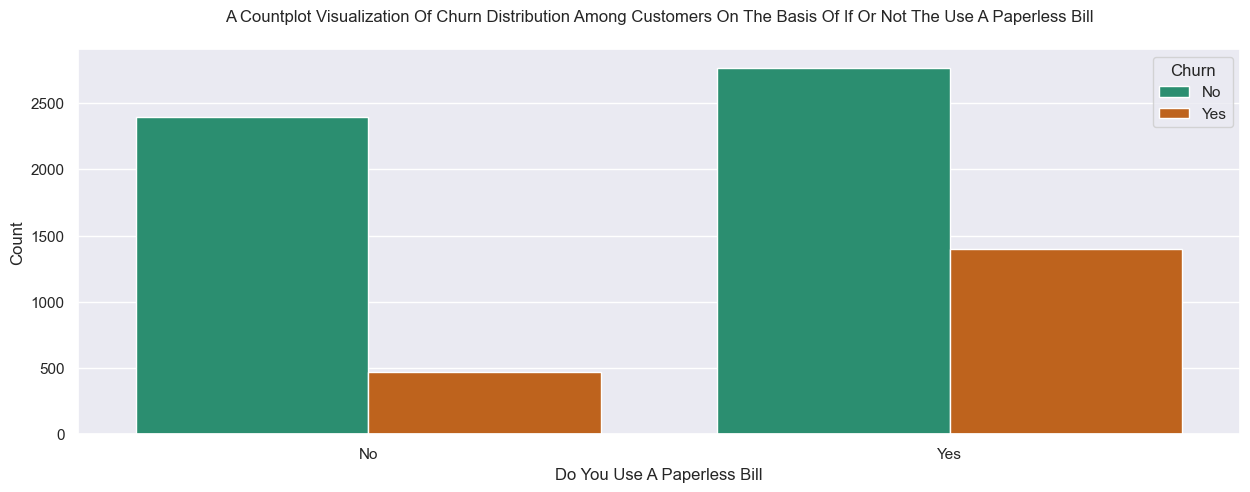

In [220]:
plt.figure(figsize = (15, 5))
sns.countplot(
    x = 'PaperlessBilling',
    hue = "Churn",
    data = df
    )
plt.title("A Countplot Visualization Of Churn Distribution Among Customers On The Basis Of If Or Not The Use A Paperless Bill", pad = 20)
plt.xlabel('Do You Use A Paperless Bill')
plt.ylabel('Count')
plt.show()

it seems customers prefer bills in the traditional manner rather than using a paperless bill evidence in the analysis of churn versus paperless billing it is seen that customers who do not use a paperless bill have a higer non churn rate as compared to customers who use a paperless bill 

# What Is The Churn Rate Among Customers Based On Thier Prefered Payment Method?

In [221]:
(df.groupby("PaymentMethod")['Churn'].value_counts(normalize = True) * 100 ).round(1).to_frame()

proportion
PaymentMethod             Churn            
Bank transfer (automatic) No           83.3
                          Yes          16.7
Credit card (automatic)   No           84.7
                          Yes          15.3
Electronic check          No           54.7
                          Yes          45.3
Mailed check              No           80.8
                          Yes          19.2

As analyzed it seen that majority of customers used an electronic check for payments and the second most used payment method is the mailded check followed by the Automatic Bank transfer and the least used is the Automatic Credit card payment method

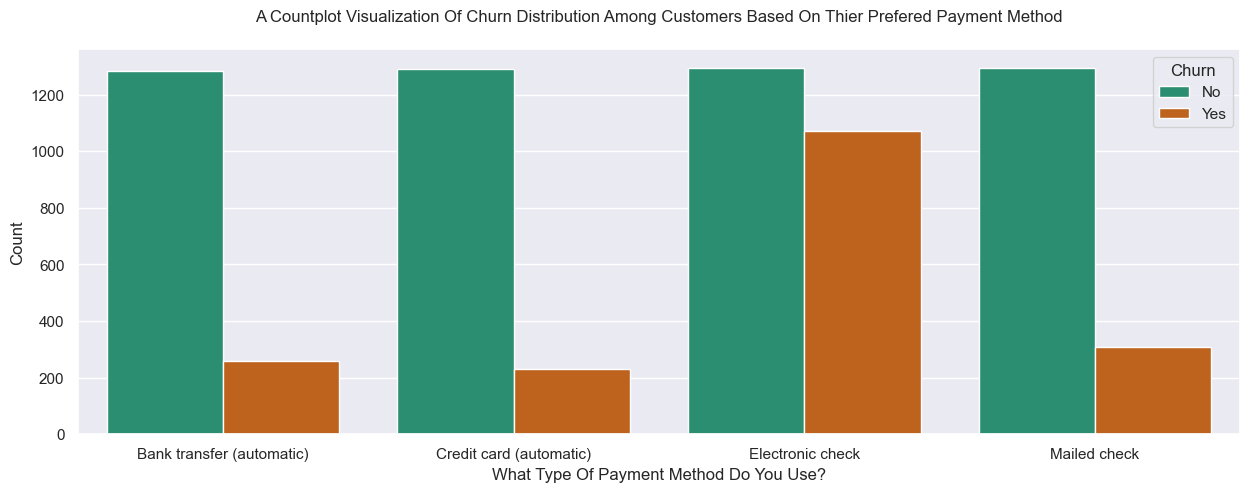

In [222]:
plt.figure(figsize = (15, 5))
sns.countplot(
    x = 'PaymentMethod',
    hue = "Churn",
    data = df
    )
plt.title("A Countplot Visualization Of Churn Distribution Among Customers Based On Thier Prefered Payment Method", pad = 20)
plt.xlabel('What Type Of Payment Method Do You Use?')
plt.ylabel('Count')
plt.show()

The Automatic Credit card payment method has the lowest churn rate and the highest non Churn rate  followed by the automatic Bank transfer, the Mailed check and lastly the Electronic Check

## What is the distribution of monthly and total charges among customer?

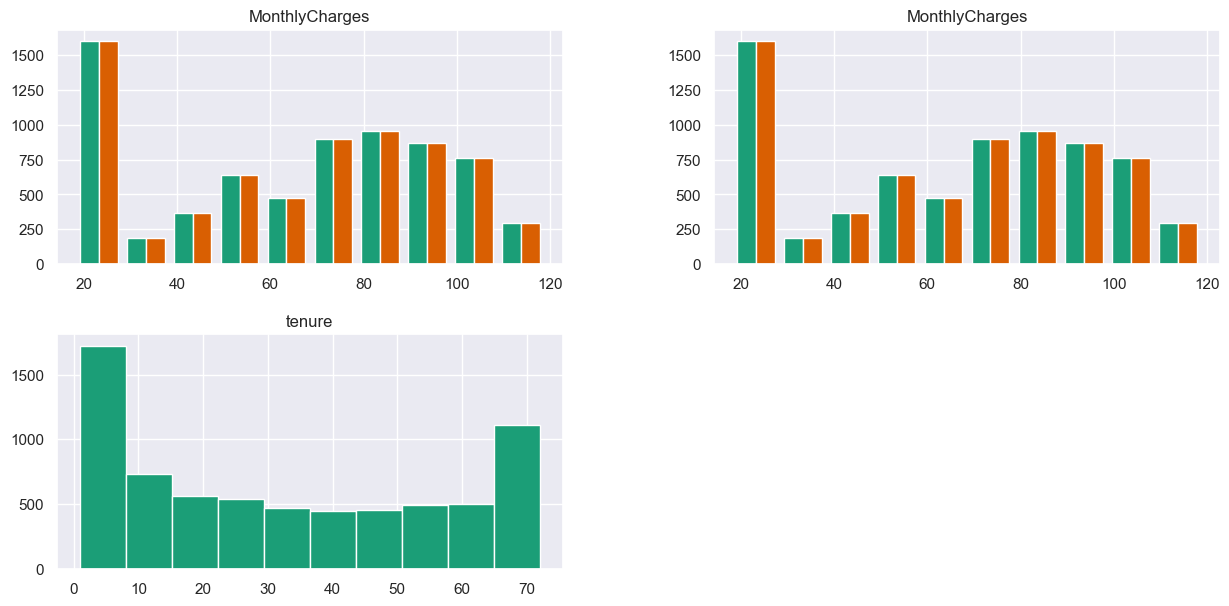

In [223]:

df[["MonthlyCharges", "TotalCharges", "tenure"]].hist(figsize = (15,7))
plt.show()

# Model training 

## Preprocessing data

### Feature Engineering

In [224]:
df['tenure_year'] = df['tenure'] / 12

### Categorical Encoding

In [225]:
model_df = pd.get_dummies(df, columns = cat_cols, drop_first = True)

In [226]:
model_df.head()

,tenure,MonthlyCharges,TotalCharges,tenure_year,gender_Male,SeniorCitizen_Yes,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,1,29.85,29.85,0.083333,False,False,True,False,False,True,...,False,False,False,False,False,True,False,True,False,False
1,34,56.95,1889.50,2.833333,True,False,False,False,True,False,...,False,False,False,True,False,False,False,False,True,False
2,2,53.85,108.15,0.166667,True,False,False,False,True,False,...,False,False,False,False,False,True,False,False,True,True
3,45,42.30,1840.75,3.750000,True,False,False,False,False,True,...,False,False,False,True,False,False,False,False,False,False
4,2,70.70,151.65,0.166667,False,False,False,False,True,False,...,False,False,False,False,False,True,False,True,False,True


### Scaling

In [232]:
scaler = StandardScaler()
numerical_cols = ['tenure_year', 'tenure', 'MonthlyCharges', 'TotalCharges']
model_df[['scaled_' + col for col in numerical_cols]] = scaler.fit_transform(model_df[numerical_cols])

In [228]:
model_df.head()

,tenure,MonthlyCharges,TotalCharges,tenure_year,gender_Male,SeniorCitizen_Yes,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes,scaled_MonthlyCharges,scaled_TotalCharges
0,1,29.85,29.85,0.083333,False,False,True,False,False,True,...,False,False,False,True,False,True,False,False,-1.161694,-0.994194
1,34,56.95,1889.50,2.833333,True,False,False,False,True,False,...,False,True,False,False,False,False,True,False,-0.260878,-0.173740
2,2,53.85,108.15,0.166667,True,False,False,False,True,False,...,False,False,False,True,False,False,True,True,-0.363923,-0.959649
3,45,42.30,1840.75,3.750000,True,False,False,False,False,True,...,False,True,False,False,False,False,False,False,-0.747850,-0.195248
4,2,70.70,151.65,0.166667,False,False,False,False,True,False,...,False,False,False,True,False,True,False,True,0.196178,-0.940457


In [233]:
model_df.columns

Index(['tenure', 'MonthlyCharges', 'TotalCharges', 'tenure_year',
       'gender_Male', 'SeniorCitizen_Yes', 'Partner_Yes', 'Dependents_Yes',
       'PhoneService_Yes', 'MultipleLines_No phone service',
       'MultipleLines_Yes', 'InternetService_Fiber optic',
       'InternetService_No', 'OnlineSecurity_No internet service',
       'OnlineSecurity_Yes', 'OnlineBackup_No internet service',
       'OnlineBackup_Yes', 'DeviceProtection_No internet service',
       'DeviceProtection_Yes', 'TechSupport_No internet service',
       'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check',
       'Churn_Yes', 'scaled_MonthlyCharges', 'scaled_TotalCharges',
       'scaled_tenure_year', 'scaled_tenure'],
      dtype='obje

## Feature variable 

In [235]:
cols_drop = ['tenure', 'MonthlyCharges', 'TotalCharges', 'tenure_year', 'Churn_Yes']
x = model_df.drop(cols_drop, axis = 1)


## Target variable

In [236]:
y = model_df["Churn_Yes"]

## Splitting data set for training and testing

In [237]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state = 42, stratify = y)

# Logistic Regression

In [238]:
#instantiating model
log = LogisticRegression(
    C = 1.0,
    penalty = 'l2',
    solver = 'lbfgs',
    class_weight = None,
    )

In [ ]:
#lr_param_grid = {
#    'C': [0.001, 0.01, 0.1, 1, 10, 100],
#    'penalty': ['l1', 'l2'],
#    'solver': ['liblinear', 'saga'],
#    'class_weight': [None, 'balanced']
#}

In [ ]:
#lr_tune = GridSearchCV(
#    log, 
#    lr_param_grid, 
#    cv = kf,              # 5-fold cross-validation
#    n_jobs=-1,            # Use all available cores
#    verbose=1,            # Print progress
#    scoring='accuracy',   # Metric to optimize
#    return_train_score=True
#)

In [ ]:
#lr_tune.fit(x_train, y_train)

In [ ]:
#print(lr_tune.best_params_, lr_tune.best_score_)

In [239]:
mse_cv = cross_val_score(
    log, 
    x_train,
    y_train,
    cv = 10,
    n_jobs = -1
)

In [240]:
print(f"CV MSE:{mse_cv.mean()}")

CV MSE:0.8011011890037765


In [241]:
log.fit(x_train, y_train)

LogisticRegression()

In [242]:
log_train = log.predict(x_train)

In [243]:
log_y_pred_test = log.predict(x_test)

In [244]:
training_score = accuracy_score(log_train, y_train)
training_score

0.8055668427468509

In [245]:
test_score = accuracy_score(log_y_pred_test, y_test) 
test_score

0.8061611374407583

In [246]:
log_confused_test = confusion_matrix(log_y_pred_test, y_test)
print(log_confused_test)

[[1383  243]
 [ 166  318]]


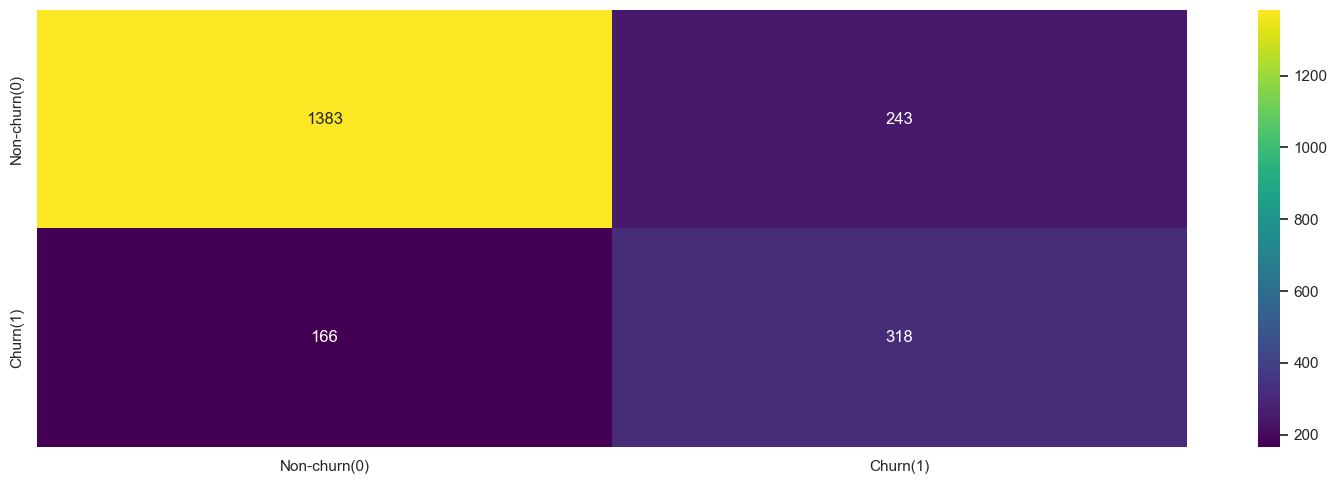

In [247]:
plt.figure(figsize=(15, 5))  
sns.heatmap(
    log_confused_test,
    annot = True,
    cmap ='viridis',
    fmt = 'g',
    xticklabels = ["Non-churn(0)","Churn(1)"],
    yticklabels = ["Non-churn(0)","Churn(1)"],
)
plt.tight_layout()
plt.show()

In [248]:
log_test_proba = log.predict_proba(x_test)[:,1]

0.8379444388824254


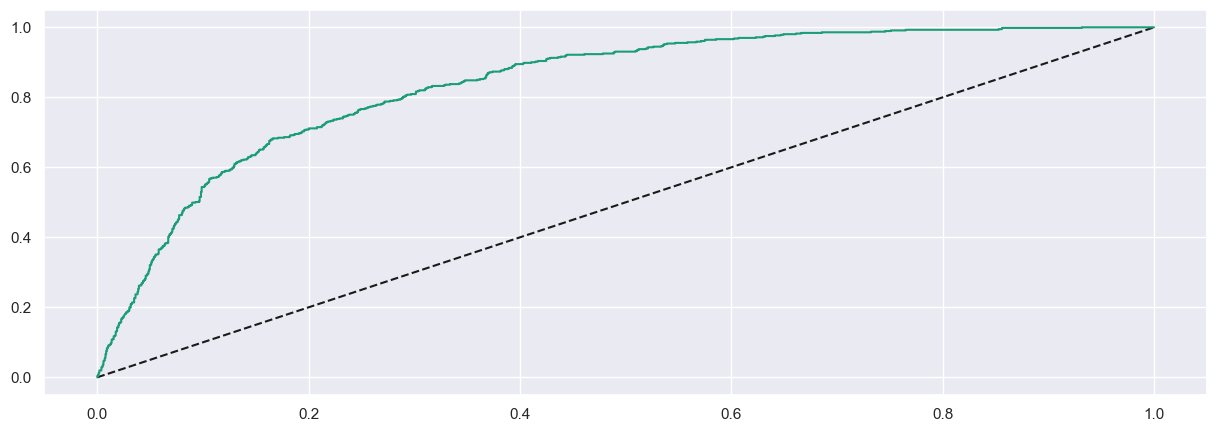

In [249]:
plt.figure(figsize = (15, 5))
fpr, tpr, threshold = roc_curve(y_test, log_test_proba)
plt.plot([0, 1], [0, 1], "k--")
print(roc_auc_score(y_test, log_test_proba))
plt.plot(fpr, tpr)
plt.show()

In [250]:
print(classification_report(y_train, log_train))

              precision    recall  f1-score   support

       False       0.85      0.90      0.87      3614
        True       0.66      0.56      0.60      1308

    accuracy                           0.81      4922
   macro avg       0.75      0.73      0.74      4922
weighted avg       0.80      0.81      0.80      4922



In [251]:
print(classification_report(y_test, log_y_pred_test))

              precision    recall  f1-score   support

       False       0.85      0.89      0.87      1549
        True       0.66      0.57      0.61       561

    accuracy                           0.81      2110
   macro avg       0.75      0.73      0.74      2110
weighted avg       0.80      0.81      0.80      2110



# Feature Importance With Random Forest

In [252]:
rf_model = RandomForestClassifier()
rf_model.fit(x_train, y_train)

RandomForestClassifier()

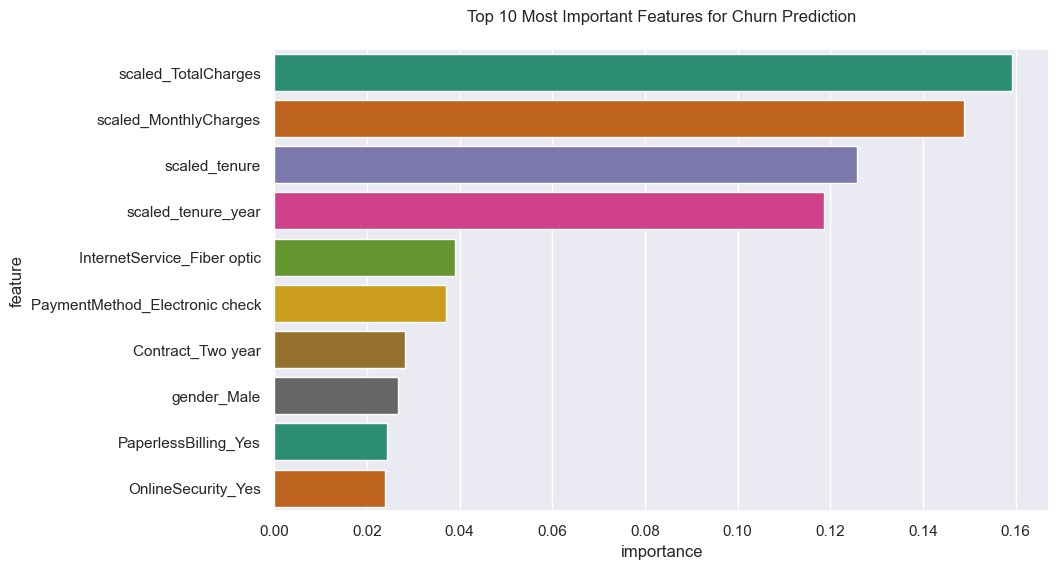

Exception ignored in: <function ResourceTracker.__del__ at 0x10c4ea520>
Traceback (most recent call last):
  File "/Users/obi/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/Users/obi/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/Users/obi/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x10b686520>
Traceback (most recent call last):
  File "/Users/obi/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/Users/obi/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/Users/obi/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x10fe5a5

In [253]:
# Get feature importance
feature_importance = pd.DataFrame({
    'feature': x.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False).head(10)

# Plot feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feature_importance, palette = 'Dark2')
plt.title('Top 10 Most Important Features for Churn Prediction', pad = 20)
sns.set_style('darkgrid')
plt.show()